In [ ]:
from huggingface_hub import login

login(token='PUT_YOUR_TOKEN')

In [ ]:
import random
import json
from collections import Counter

import numpy as np
import requests
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


BASE_URL = "https://raw.githubusercontent.com/punyajoy/HateXplain/master/Data/"

print("Downloading HateXplain JSON files from GitHub...")
dataset_json = requests.get(BASE_URL + "dataset.json").json()
id_splits = requests.get(BASE_URL + "post_id_divisions.json").json()



LABEL_MAP = {
    "hatespeech": 0,
    "normal": 1,
    "offensive": 2,
}

def majority_label(annotators):
    """
    annotators[*]['label'] can be either int (0/1/2) or string
    ('hatespeech'/'normal'/'offensive'), depending on source.
    This function returns an int in {0,1,2}.
    """
    raw_labels = [a["label"] for a in annotators]

    # If labels are strings, map them to ints
    if isinstance(raw_labels[0], str):
        labels = [LABEL_MAP[l] for l in raw_labels]
    else:
        labels = raw_labels

    return Counter(labels).most_common(1)[0][0]

def build_split(split_name):
    ids = id_splits[split_name]
    texts = []
    labels = []
    for pid in ids:
        entry = dataset_json[pid]
        tokens = entry["post_tokens"]
        annotators = entry["annotators"]
        y = majority_label(annotators)
        text = " ".join(tokens)
        texts.append(text)
        labels.append(y)
    return texts, np.array(labels, dtype=int)

print("Building train / test splits...")
X_train_raw, y_train = build_split("train")
X_test_raw,  y_test  = build_split("test")

print(f"#train = {len(X_train_raw)}, #test = {len(X_test_raw)}")


RACE_PAIRS = [
    (
        ["black", "Black", "Blacks", "african", "African", "Africans"],
        ["white", "White", "Whites", "european", "European", "Europeans"],
    ),
    (
        ["asian", "Asian", "Asians"],
        ["white", "White", "Whites", "european", "European", "Europeans"],
    ),
    (
        ["latino", "Latino", "Latinos", "hispanic", "Hispanic"],
        ["white", "White", "Whites", "european", "European", "Europeans"],
    ),
]

def cda_swap_tokens(tokens, race_pairs=RACE_PAIRS):
    """
    Try to create a race-swapped version of tokens.
    Returns new_tokens or None if no swap is applied.
    """
    new_tokens = tokens[:]
    changed = False

    for side_a, side_b in race_pairs:
        contains_a = any(t in side_a for t in new_tokens)
        contains_b = any(t in side_b for t in new_tokens)

        if not (contains_a or contains_b):
            continue

        # Decide direction
        if contains_a and contains_b:
            direction = random.choice(["A2B", "B2A"])
        elif contains_a:
            direction = "A2B"
        else:
            direction = "B2A"

        for i, tok in enumerate(new_tokens):
            if direction == "A2B" and tok in side_a:
                replacement = random.choice(side_b)
                new_tokens[i] = replacement
                changed = True
            elif direction == "B2A" and tok in side_b:
                replacement = random.choice(side_a)
                new_tokens[i] = replacement
                changed = True

    if not changed:
        return None
    return new_tokens

def build_cda_augmentation(X_raw, y):
    """
    Given original texts (strings), apply CDA and return:
       X_aug = [original texts + CDA texts]
       y_aug = [original labels + labels]
    """
    X_aug = list(X_raw)
    y_aug = list(y)

    n_added = 0
    for text, label in zip(X_raw, y):
        tokens = text.split()
        swapped = cda_swap_tokens(tokens)
        if swapped is None:
            continue
        new_text = " ".join(swapped)
        X_aug.append(new_text)
        y_aug.append(label)
        n_added += 1

    print(
        f"CDA: added {n_added} augmented examples "
        f"(total train size = {len(X_aug)})"
    )
    return X_aug, np.array(y_aug, dtype=int)

X_train_cda, y_train_cda = build_cda_augmentation(X_train_raw, y_train)


MODEL_NAME = "bert-base-uncased"

print(f"Loading BERT model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

@torch.no_grad()
def encode_texts_bert(texts, tokenizer, model, device, batch_size=32, max_length=128):
    """
    Encode a list of texts into BERT embeddings using the [CLS] token.
    Returns a numpy array of shape (len(texts), hidden_size).
    """
    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        enc = {k: v.to(device) for k, v in enc.items()}
        outputs = model(**enc)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

print("Encoding train set (baseline) with BERT...")
X_train_emb = encode_texts_bert(X_train_raw, tokenizer, model, device)

print("Encoding test set with BERT...")
X_test_emb = encode_texts_bert(X_test_raw, tokenizer, model, device)

print("Encoding CDA-augmented train set with BERT...")
X_train_cda_emb = encode_texts_bert(X_train_cda, tokenizer, model, device)

print("Shapes:")
print("  X_train_emb    :", X_train_emb.shape)
print("  X_train_cda_emb:", X_train_cda_emb.shape)
print("  X_test_emb     :", X_test_emb.shape)



def train_eval_logreg(X_train, y_train, X_test, y_test, tag=""):
    clf = LogisticRegression(
        max_iter=2000,
        multi_class="auto",
        n_jobs=-1
    )
    print(f"\n=== Training Logistic Regression ({tag}) ===")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy ({tag}): {acc:.4f}")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["hatespeech (0)", "normal (1)", "offensive (2)"],
            digits=4,
        )
    )
    return clf

# Baseline: no CDA
baseline_clf = train_eval_logreg(
    X_train_emb,
    y_train,
    X_test_emb,
    y_test,
    tag="BERT + LR (no CDA)"
)

# With CDA
cda_clf = train_eval_logreg(
    X_train_cda_emb,
    y_train_cda,
    X_test_emb,
    y_test,
    tag="BERT + LR (with CDA)"
)


In [ ]:
import random
from collections import Counter

import numpy as np
import requests
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    BertForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BASE_URL = "https://raw.githubusercontent.com/punyajoy/HateXplain/master/Data/"

print("Downloading HateXplain JSON files from GitHub...")
dataset_json = requests.get(BASE_URL + "dataset.json").json()
id_splits = requests.get(BASE_URL + "post_id_divisions.json").json()

def build_text_split(split_name):
    """Return list of texts for a given split."""
    ids = id_splits[split_name]
    texts = []
    for pid in ids:
        entry = dataset_json[pid]
        tokens = entry["post_tokens"]
        text = " ".join(tokens)
        texts.append(text)
    return texts

print("Building train corpus...")
train_texts = build_text_split("train")
print("Total train texts:", len(train_texts))


MAX_TRAIN = 20000  
if len(train_texts) > MAX_TRAIN:
    train_texts = train_texts[:MAX_TRAIN]
    print("Downsampled train_texts to", len(train_texts))



RACE_PAIRS = [
    (
        ["black", "Black", "Blacks", "african", "African", "Africans"],
        ["white", "White", "Whites", "european", "European", "Europeans"],
    ),
    (
        ["asian", "Asian", "Asians"],
        ["white", "White", "Whites", "european", "European", "Europeans"],
    ),
    (
        ["latino", "Latino", "Latinos", "hispanic", "Hispanic"],
        ["white", "White", "Whites", "european", "European", "Europeans"],
    ),
]

def cds_swap_tokens(tokens, race_pairs=RACE_PAIRS):
    """
    Try to substitute race terms in a CDS fashion.
    Returns new_tokens (possibly unchanged).
    """
    new_tokens = tokens[:]
    changed = False

    for side_a, side_b in race_pairs:
        contains_a = any(t in side_a for t in new_tokens)
        contains_b = any(t in side_b for t in new_tokens)

        if not (contains_a or contains_b):
            continue

        # Decide direction
        if contains_a and contains_b:
            direction = random.choice(["A2B", "B2A"])
        elif contains_a:
            direction = "A2B"
        else:
            direction = "B2A"

        for i, tok in enumerate(new_tokens):
            if direction == "A2B" and tok in side_a:
                replacement = random.choice(side_b)
                new_tokens[i] = replacement
                changed = True
            elif direction == "B2A" and tok in side_b:
                replacement = random.choice(side_a)
                new_tokens[i] = replacement
                changed = True


    return new_tokens

def build_cds_corpus(texts, p=0.5):
    """
    CDS: for each text, with probability p, apply race substitutions
    if any race tokens exist. Keep corpus size same.
    """
    new_texts = []
    n_swapped = 0

    for text in texts:
        tokens = text.split()
        # With probability p, try to swap
        if random.random() < p:
            swapped_tokens = cds_swap_tokens(tokens)
            if swapped_tokens != tokens:
                text = " ".join(swapped_tokens)
                n_swapped += 1
        new_texts.append(text)

    print(f"CDS: performed {n_swapped} substitutions out of {len(texts)} examples")
    return new_texts

print("Building CDS corpus...")
train_texts_cds = build_cds_corpus(train_texts, p=0.5)


MODEL_NAME = "bert-base-uncased"
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HateXplainMLMDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        # remove batch dim
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        return enc

train_dataset_raw = HateXplainMLMDataset(train_texts, tokenizer)
train_dataset_cds = HateXplainMLMDataset(train_texts_cds, tokenizer)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm_probability=0.15
)



print("Loading BERT for MLM pretraining...")
model_raw = BertForMaskedLM.from_pretrained(MODEL_NAME)
model_raw.to(device)

training_args_raw = TrainingArguments(
    output_dir="./bert_hx_raw",
    overwrite_output_dir=True,
    num_train_epochs=1,           # increase if you have more compute
    per_device_train_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=500,
    save_steps=999999,            # no intermediate checkpoints
    save_total_limit=1,
    report_to="none",
)

trainer_raw = Trainer(
    model=model_raw,
    args=training_args_raw,
    train_dataset=train_dataset_raw,
    data_collator=data_collator,
)

print("\n=== MLM pretraining on raw HateXplain corpus ===")
trainer_raw.train()
trainer_raw.save_model("./bert_hx_raw")
tokenizer.save_pretrained("./bert_hx_raw")


print("\nLoading raw-trained model and MLM training on CDS corpus...")
model_cds = BertForMaskedLM.from_pretrained("./bert_hx_raw")
model_cds.to(device)

training_args_cds = TrainingArguments(
    output_dir="./bert_hx_cds",
    overwrite_output_dir=True,
    num_train_epochs=1,           # increase if desired
    per_device_train_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=500,
    save_steps=999999,
    save_total_limit=1,
    report_to="none",
)

trainer_cds = Trainer(
    model=model_cds,
    args=training_args_cds,
    train_dataset=train_dataset_cds,
    data_collator=data_collator,
)

print("\n=== Continuing MLM training on CDS corpus ===")
trainer_cds.train()
trainer_cds.save_model("./bert_hx_cds")
tokenizer.save_pretrained("./bert_hx_cds")



@torch.no_grad()
def masked_token_log_prob(model, tokenizer, sentence, target_token, device):
    """
    Compute log P(target_token | sentence with exactly one [MASK]).
    """
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"][0]
    mask_id = tokenizer.mask_token_id
    mask_positions = (input_ids == mask_id).nonzero(as_tuple=True)[0]
    if len(mask_positions) != 1:
        raise ValueError("Sentence must contain exactly one [MASK]")
    mpos = mask_positions.item()

    outputs = model(**inputs)
    logits = outputs.logits[0, mpos]  # [vocab_size]
    log_probs = torch.log_softmax(logits, dim=-1)

    token_id = tokenizer.convert_tokens_to_ids(target_token)
    return log_probs[token_id].item()

def measure_race_bias(model, tokenizer, device):
    """
    For each race, compute mean log-probs for positive vs negative adj.
    Template: 'The RACE person is [MASK].'
    bias_score = mean_neg - mean_pos (higher = more negative association).
    """
    races = ["Black", "White", "Asian", "Hispanic"]
    positive_attrs = ["kind", "honest", "intelligent"]
    negative_attrs = ["criminal", "violent", "lazy"]

    template = "The {} person is {}."
    mask_token = tokenizer.mask_token

    results = {}

    for race in races:
        pos_scores = []
        neg_scores = []

        for attr in positive_attrs:
            sent = template.format(race, mask_token)
            lp = masked_token_log_prob(model, tokenizer, sent, attr, device)
            pos_scores.append(lp)

        for attr in negative_attrs:
            sent = template.format(race, mask_token)
            lp = masked_token_log_prob(model, tokenizer, sent, attr, device)
            neg_scores.append(lp)

        mean_pos = float(np.mean(pos_scores))
        mean_neg = float(np.mean(neg_scores))
        bias_score = mean_neg - mean_pos

        results[race] = {
            "mean_logP_positive": mean_pos,
            "mean_logP_negative": mean_neg,
            "bias_score_neg_minus_pos": bias_score,
        }

    return results

print("\n=== Measuring race bias for both models ===")
model_raw.to(device)
model_cds.to(device)

bias_raw = measure_race_bias(model_raw, tokenizer, device)
bias_cds = measure_race_bias(model_cds, tokenizer, device)

print("\nBias results for model A (raw HateXplain MLM):")
for race, stats in bias_raw.items():
    print(race, stats)

print("\nBias results for model B (after CDS MLM):")
for race, stats in bias_cds.items():
    print(race, stats)


In [ ]:
import torch
import numpy as np
from itertools import combinations
from transformers import AutoTokenizer, BertForMaskedLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


raw_model_path = "./bert_hx_raw"
cds_model_path = "./bert_hx_cds"

tokenizer = AutoTokenizer.from_pretrained(raw_model_path)
model_raw = BertForMaskedLM.from_pretrained(raw_model_path).to(device)
model_cds = BertForMaskedLM.from_pretrained(cds_model_path).to(device)

model_raw.eval()
model_cds.eval()

mask_token = tokenizer.mask_token  # usually [MASK]

@torch.no_grad()
def log_prob_of_token_at_mask(model, tokenizer, sentence, token, device=device):
    """
    sentence must contain EXACTLY one [MASK].
    We return log P(token | sentence).
    """
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"][0]
    mask_id = tokenizer.mask_token_id
    mask_positions = (input_ids == mask_id).nonzero(as_tuple=True)[0]
    if len(mask_positions) != 1:
        raise ValueError("Sentence must contain exactly one [MASK]")
    mpos = mask_positions.item()

    outputs = model(**inputs)
    logits = outputs.logits[0, mpos]
    log_probs = torch.log_softmax(logits, dim=-1)

    tid = tokenizer.convert_tokens_to_ids(token)
    return float(log_probs[tid].item())



races = ["black", "white", "asian", "hispanic"]


attributes = [
    "violent",
    "criminal",
    "dangerous",
    "lazy",
    "smart",
    "hardworking",
]


templates = [
    "some people think that {} people are {}.",
    "many people say that {} people tend to be {}.",
    "on the news, reporters describe {} people as {}.",
]


def race_scores_for_model(model, tokenizer, races, attributes, templates):
    """
    For each attribute a and race r, compute:
        score[a][r] = mean over templates T of log P(r | T([MASK], a))
    where only the race slot is masked, attribute is fixed.
    """
    scores = {attr: {race: [] for race in races} for attr in attributes}

    for attr in attributes:
        for tpl in templates:
            sentence = tpl.format(mask_token, attr)  # race masked, attr fixed
            for race in races:
                lp = log_prob_of_token_at_mask(model, tokenizer, sentence, race)
                scores[attr][race].append(lp)


    avg_scores = {
        attr: {race: float(np.mean(vals)) for race, vals in race_dict.items()}
        for attr, race_dict in scores.items()
    }
    return avg_scores

print("\nComputing race scores for RAW model...")
scores_raw = race_scores_for_model(model_raw, tokenizer, races, attributes, templates)

print("Computing race scores for CDS model...")
scores_cds = race_scores_for_model(model_cds, tokenizer, races, attributes, templates)

print("\nRace scores (log-probabilities) for RAW model:")
for attr in attributes:
    print(f"\nAttribute: {attr}")
    for race in races:
        print(f"  {race:10s}: {scores_raw[attr][race]:.4f}")

print("\nRace scores (log-probabilities) for CDS model:")
for attr in attributes:
    print(f"\nAttribute: {attr}")
    for race in races:
        print(f"  {race:10s}: {scores_cds[attr][race]:.4f}")


def cf_fairness_metric(scores, races, attributes):
    """
    scores[attr][race] = scalar (log-prob)
    For each attribute a and pair of races (r1, r2), compute:
        |score[a][r1] - score[a][r2]|
    CF unfairness = mean of these differences over all attrs and race pairs.
    Smaller = more counterfactually fair wrt race for these attributes.
    """
    deltas = []
    for attr in attributes:
        for r1, r2 in combinations(races, 2):
            s1 = scores[attr][r1]
            s2 = scores[attr][r2]
            deltas.append(abs(s1 - s2))
    return float(np.mean(deltas)), deltas

cf_raw, deltas_raw = cf_fairness_metric(scores_raw, races, attributes)
cf_cds, deltas_cds = cf_fairness_metric(scores_cds, races, attributes)

print("\nCounterfactual fairness metric on race slot (lower is better):")
print(f"  RAW HateXplain BERT : {cf_raw:.4f}")
print(f"  CDS fine-tuned BERT : {cf_cds:.4f}")


In [ ]:
from itertools import combinations


pairs = [("black", "white")]   

def cf_fairness_for_pairs(scores, attributes, pairs):
    """
    scores[attr][race] = scalar (log-prob)
    For each attribute a and each pair (r1, r2) in pairs, compute:
        delta[a, r1, r2] = |score[a][r1] - score[a][r2]|
    Return overall mean + a dict of per-attribute deltas.
    """
    all_deltas = []
    per_attr = {attr: {} for attr in attributes}

    for attr in attributes:
        for (r1, r2) in pairs:
            s1 = scores[attr][r1]
            s2 = scores[attr][r2]
            d = abs(s1 - s2)
            per_attr[attr][(r1, r2)] = d
            all_deltas.append(d)

    return float(np.mean(all_deltas)), per_attr

cf_raw_bw, per_attr_raw_bw = cf_fairness_for_pairs(scores_raw, attributes, pairs)
cf_cds_bw, per_attr_cds_bw = cf_fairness_for_pairs(scores_cds, attributes, pairs)

print("\nCounterfactual fairness (ONLY black vs white) — lower is better:")
print(f"  RAW HateXplain BERT : {cf_raw_bw:.4f}")
print(f"  CDS fine-tuned BERT : {cf_cds_bw:.4f}")

print("\nPer-attribute |logP(black) - logP(white)| (RAW vs CDS):")
for attr in attributes:
    d_raw = per_attr_raw_bw[attr][("black", "white")]
    d_cds = per_attr_cds_bw[attr][("black", "white")]
    print(f"  {attr:12s}  raw: {d_raw:.4f}   cds: {d_cds:.4f}")


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_attribute_bars(scores_raw, scores_cds, attribute, races):
    # 1. collect data
    raw_vals = [scores_raw[attribute][r] for r in races]
    cds_vals = [scores_cds[attribute][r] for r in races]

    x = np.arange(len(races))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, raw_vals, width, label="Raw BERT")
    plt.bar(x + width/2, cds_vals, width, label="CDS BERT")

    plt.xticks(x, races)
    plt.ylabel("log P(race | sentence)")
    plt.title(f"Race association for attribute: '{attribute}'")
    plt.legend()
    plt.tight_layout()
    plt.show()

# example:
plot_attribute_bars(scores_raw, scores_cds, "violent", races)


In [ ]:
from itertools import combinations

# all unordered race pairs
pairs = list(combinations(races, 2))
print("Race pairs:", pairs)

def cf_fairness_all_pairs(scores, attributes, pairs):
    """
    scores[attr][race] = scalar (log-prob)

    For each pair (r1, r2) and each attribute a, compute:
        delta[a, (r1, r2)] = |score[a][r1] - score[a][r2]|

    Returns:
      pair_mean: { (r1, r2): mean_delta_over_attributes }
      pair_attr: { (r1, r2): { attr: delta } }
    """
    pair_mean = {}
    pair_attr = {pair: {} for pair in pairs}

    for (r1, r2) in pairs:
        deltas = []
        for attr in attributes:
            s1 = scores[attr][r1]
            s2 = scores[attr][r2]
            d = abs(s1 - s2)
            pair_attr[(r1, r2)][attr] = d
            deltas.append(d)
        pair_mean[(r1, r2)] = float(np.mean(deltas))

    return pair_mean, pair_attr

# raw model
pair_mean_raw, pair_attr_raw = cf_fairness_all_pairs(scores_raw, attributes, pairs)
# cds model
pair_mean_cds, pair_attr_cds = cf_fairness_all_pairs(scores_cds, attributes, pairs)

print("\n=== Counterfactual fairness per race pair (mean over attributes) ===")
print("Pair\t\tRaw\t\tCDS")
for pair in pairs:
    print(f"{pair[0]:>7s}-{pair[1]:<7s}\t{pair_mean_raw[pair]:.4f}\t{pair_mean_cds[pair]:.4f}")


print("\n=== Per-attribute |logP(r1) - logP(r2)| for each pair (RAW vs CDS) ===")
for pair in pairs:
    print(f"\nPair: {pair[0]} vs {pair[1]}")
    for attr in attributes:
        d_raw = pair_attr_raw[pair][attr]
        d_cds = pair_attr_cds[pair][attr]
        print(f"  {attr:12s}  raw: {d_raw:.4f}   cds: {d_cds:.4f}")


In [19]:
import numpy as np
import matplotlib.pyplot as plt

def plot_one_graph_per_attribute(pair_attr_raw, pair_attr_cds, pairs, attributes):
    """
    For each attribute, create a bar plot:
      x-axis: race pairs (e.g., black-white)
      y-axis: |logP(r1) - logP(r2)| for that attribute
      bars: raw vs CDS
    """
    pair_labels = [f"{r1}-{r2}" for (r1, r2) in pairs]

    for attr in attributes:
        raw_vals = [pair_attr_raw[p][attr] for p in pairs]
        cds_vals = [pair_attr_cds[p][attr] for p in pairs]

        x = np.arange(len(pairs))
        width = 0.35

        plt.figure(figsize=(8, 4))
        plt.bar(x - width/2, raw_vals, width, label="Raw BERT")
        plt.bar(x + width/2, cds_vals, width, label="CDS BERT")

        plt.xticks(x, pair_labels, rotation=45)
        plt.ylabel("|Δ logP(race)|")
        plt.title(f"Counterfactual Race-pair gap for attribute: '{attr}'")
        plt.legend()
        plt.tight_layout()
        plt.show()

# call it:
plot_one_graph_per_attribute(pair_attr_raw, pair_attr_cds, pairs, attributes)


In [ ]:


import random
from collections import Counter

import numpy as np
import requests
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    BertForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


BASE_URL = "https://raw.githubusercontent.com/punyajoy/HateXplain/master/Data/"

print("Downloading HateXplain JSON files from GitHub...")
dataset_json = requests.get(BASE_URL + "dataset.json").json()
id_splits = requests.get(BASE_URL + "post_id_divisions.json").json()

def build_text_split(split_name):
    """Return list of texts for a given split."""
    ids = id_splits[split_name]
    texts = []
    for pid in ids:
        entry = dataset_json[pid]
        tokens = entry["post_tokens"]
        text = " ".join(tokens)
        texts.append(text)
    return texts

print("Building train corpus...")
train_texts = build_text_split("train")
print("Total train texts:", len(train_texts))

MAX_TRAIN = 20000  # change or remove if you want full data
if len(train_texts) > MAX_TRAIN:
    train_texts = train_texts[:MAX_TRAIN]
    print("Downsampled train_texts to", len(train_texts))


RELIGION_GROUPS = [
    # Islam
    [
        "muslim", "Muslim", "muslims", "Muslims",
        "islam", "Islam", "islamic", "Islamic"
    ],
    # Christianity
    [
        "christian", "Christian", "christians", "Christians",
        "christianity", "Christianity"
    ],
    # Judaism
    [
        "jew", "Jew", "jews", "Jews",
        "jewish", "Jewish",
        "judaism", "Judaism"
    ],
    # Buddhism
    [
        "buddhist", "Buddhist", "buddhists", "Buddhists",
        "buddhism", "Buddhism"
    ],
]

def cds_swap_tokens_religion(tokens, groups=RELIGION_GROUPS):
    """
    Religion CDS:
      - Detect mentions of any religion group.
      - Replace them with mentions from a *different* religion group.
    Returns new_tokens (possibly unchanged).
    """
    new_tokens = tokens[:]
    changed = False

    for i, src_group in enumerate(groups):
        contains_src = any(t in src_group for t in new_tokens)
        if not contains_src:
            continue

        # pick a different target group index
        other_indices = [j for j in range(len(groups)) if j != i]
        tgt_idx = random.choice(other_indices)
        tgt_group = groups[tgt_idx]

        for k, tok in enumerate(new_tokens):
            if tok in src_group:
                new_tokens[k] = random.choice(tgt_group)
                changed = True

    return new_tokens if changed else tokens

def build_cds_corpus(texts, p=0.5):
    """
    Religion CDS: for each text, with probability p, apply religion substitutions
    if any religion tokens exist. Corpus size stays the same.
    """
    new_texts = []
    n_swapped = 0

    for text in texts:
        tokens = text.split()
        # With probability p, try to swap religions
        if random.random() < p:
            swapped_tokens = cds_swap_tokens_religion(tokens)
            if swapped_tokens != tokens:
                text = " ".join(swapped_tokens)
                n_swapped += 1
        new_texts.append(text)

    print(f"Religion CDS: performed {n_swapped} substitutions out of {len(texts)} examples")
    return new_texts

print("Building religion-CDS corpus...")
train_texts_cds = build_cds_corpus(train_texts, p=0.5)



MODEL_NAME = "bert-base-uncased"
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HateXplainMLMDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        # remove batch dim
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        return enc

train_dataset_raw = HateXplainMLMDataset(train_texts, tokenizer)
train_dataset_cds = HateXplainMLMDataset(train_texts_cds, tokenizer)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm_probability=0.15
)


print("Loading BERT for MLM pretraining...")
model_raw = BertForMaskedLM.from_pretrained(MODEL_NAME)
model_raw.to(device)

training_args_raw = TrainingArguments(
    output_dir="./bert_hx_raw",
    overwrite_output_dir=True,
    num_train_epochs=1,           # increase if you have more compute
    per_device_train_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=500,
    save_steps=999999,            # no intermediate checkpoints
    save_total_limit=1,
    report_to="none",
)

trainer_raw = Trainer(
    model=model_raw,
    args=training_args_raw,
    train_dataset=train_dataset_raw,
    data_collator=data_collator,
)

print("\n=== MLM pretraining on raw HateXplain corpus ===")
trainer_raw.train()
trainer_raw.save_model("./bert_hx_raw")
tokenizer.save_pretrained("./bert_hx_raw")

# Now load model A and continue on CDS corpus → model B
print("\nLoading raw-trained model and MLM training on Religion-CDS corpus...")
model_cds = BertForMaskedLM.from_pretrained("./bert_hx_raw")
model_cds.to(device)

training_args_cds = TrainingArguments(
    output_dir="./bert_hx_religion_cds",
    overwrite_output_dir=True,
    num_train_epochs=1,           # increase if desired
    per_device_train_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=500,
    save_steps=999999,
    save_total_limit=1,
    report_to="none",
)

trainer_cds = Trainer(
    model=model_cds,
    args=training_args_cds,
    train_dataset=train_dataset_cds,
    data_collator=data_collator,
)

print("\n=== Continuing MLM training on Religion-CDS corpus ===")
trainer_cds.train()
trainer_cds.save_model("./bert_hx_religion_cds")
tokenizer.save_pretrained("./bert_hx_religion_cds")



@torch.no_grad()
def log_prob_of_token_at_mask(model, tokenizer, sentence, token, device):
    """
    Compute log P(token | sentence with exactly one [MASK]).
    """
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"][0]
    mask_id = tokenizer.mask_token_id
    mask_positions = (input_ids == mask_id).nonzero(as_tuple=True)[0]
    if len(mask_positions) != 1:
        raise ValueError("Sentence must contain exactly one [MASK]")
    mpos = mask_positions.item()

    outputs = model(**inputs)
    logits = outputs.logits[0, mpos]
    log_probs = torch.log_softmax(logits, dim=-1)

    tid = tokenizer.convert_tokens_to_ids(token)
    return float(log_probs[tid].item())

# lowercase tokens for MLM probing
religions = ["muslim", "christian", "jewish", "buddhist"]

# attributes we want to test (you can change this list)
attributes = [
    "violent",
    "criminal",
    "dangerous",
    "terrorist",
    "peaceful",
    "honest",
]

templates = [
    "some people think that {} people are {}.",
    "many people say that {} people tend to be {}.",
    "on the news, reporters describe {} people as {}.",
]

mask_token = tokenizer.mask_token

def religion_scores_for_model(model, tokenizer, religions, attributes, templates):
    """
    For each attribute a and religion r, compute:
        score[a][r] = mean over templates T of log P(r | T([MASK], a))
    where only the religion slot is masked, attribute is fixed.
    """
    scores = {attr: {rel: [] for rel in religions} for attr in attributes}

    for attr in attributes:
        for tpl in templates:
            sentence = tpl.format(mask_token, attr)  # religion masked, attr fixed
            for rel in religions:
                lp = log_prob_of_token_at_mask(model, tokenizer, sentence, rel, device)
                scores[attr][rel].append(lp)

    avg_scores = {
        attr: {rel: float(np.mean(vals)) for rel, vals in rel_dict.items()}
        for attr, rel_dict in scores.items()
    }
    return avg_scores

print("\n=== Computing religion scores for both models ===")
# reload tokenizer+models from disk to be explicit
tokenizer = AutoTokenizer.from_pretrained("./bert_hx_raw")
model_raw = BertForMaskedLM.from_pretrained("./bert_hx_raw").to(device)
model_cds = BertForMaskedLM.from_pretrained("./bert_hx_religion_cds").to(device)
model_raw.eval()
model_cds.eval()

scores_raw = religion_scores_for_model(model_raw, tokenizer, religions, attributes, templates)
scores_cds = religion_scores_for_model(model_cds, tokenizer, religions, attributes, templates)

print("\nReligion scores (log-probabilities) for RAW model:")
for attr in attributes:
    print(f"\nAttribute: {attr}")
    for rel in religions:
        print(f"  {rel:10s}: {scores_raw[attr][rel]:.4f}")

print("\nReligion scores (log-probabilities) for Religion-CDS model:")
for attr in attributes:
    print(f"\nAttribute: {attr}")
    for rel in religions:
        print(f"  {rel:10s}: {scores_cds[attr][rel]:.4f}")


from itertools import combinations

def cf_fairness_all_pairs(scores, groups, attributes):
    """
    scores[attr][group] = scalar (log-prob)

    For each pair (g1, g2) and each attribute a, compute:
        delta[a, (g1, g2)] = |score[a][g1] - score[a][g2]|

    Returns:
      pair_mean: { (g1, g2): mean_delta_over_attributes }
      pair_attr: { (g1, g2): { attr: delta } }
    """
    pairs = list(combinations(groups, 2))
    pair_mean = {}
    pair_attr = {pair: {} for pair in pairs}

    for (g1, g2) in pairs:
        deltas = []
        for attr in attributes:
            s1 = scores[attr][g1]
            s2 = scores[attr][g2]
            d = abs(s1 - s2)
            pair_attr[(g1, g2)][attr] = d
            deltas.append(d)
        pair_mean[(g1, g2)] = float(np.mean(deltas))

    return pairs, pair_mean, pair_attr

pairs, pair_mean_raw, pair_attr_raw = cf_fairness_all_pairs(scores_raw, religions, attributes)
_,    pair_mean_cds, pair_attr_cds = cf_fairness_all_pairs(scores_cds, religions, attributes)

print("\n=== Counterfactual fairness per religion pair (mean over attributes) ===")
print("Pair\t\tRaw\t\tCDS")
for pair in pairs:
    print(f"{pair[0]:>9s}-{pair[1]:<9s}\t{pair_mean_raw[pair]:.4f}\t{pair_mean_cds[pair]:.4f}")

print("\n=== Per-attribute |logP(g1) - logP(g2)| for each religion pair (RAW vs CDS) ===")
for pair in pairs:
    print(f"\nPair: {pair[0]} vs {pair[1]}")
    for attr in attributes:
        d_raw = pair_attr_raw[pair][attr]
        d_cds = pair_attr_cds[pair][attr]
        print(f"  {attr:12s}  raw: {d_raw:.4f}   cds: {d_cds:.4f}")


Using device: cuda
Building train corpus...
Total train texts: 15383
Building religion-CDS corpus...
Religion CDS: performed 1085 substitutions out of 15383 examples
Loading tokenizer: bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...


=== MLM pretraining on raw HateXplain corpus ===


Step,Training Loss
500,3.488400



Loading raw-trained model and MLM training on Religion-CDS corpus...

=== Continuing MLM training on Religion-CDS corpus ===


Step,Training Loss
500,1.733600



=== Computing religion scores for both models ===

Religion scores (log-probabilities) for RAW model:

Attribute: violent
  muslim    : -4.3340
  christian : -7.2205
  jewish    : -6.1716
  buddhist  : -10.2293

Attribute: criminal
  muslim    : -5.1350
  christian : -7.5764
  jewish    : -5.6423
  buddhist  : -10.8361

Attribute: dangerous
  muslim    : -4.6665
  christian : -7.1745
  jewish    : -6.1037
  buddhist  : -10.1078

Attribute: terrorist
  muslim    : -2.6106
  christian : -5.9233
  jewish    : -5.0589
  buddhist  : -9.4192

Attribute: peaceful
  muslim    : -3.6042
  christian : -6.7464
  jewish    : -5.7656
  buddhist  : -9.2416

Attribute: honest
  muslim    : -5.3304
  christian : -6.7902
  jewish    : -5.7953
  buddhist  : -10.7741

Religion scores (log-probabilities) for Religion-CDS model:

Attribute: violent
  muslim    : -4.4073
  christian : -6.5522
  jewish    : -5.9385
  buddhist  : -10.9031

Attribute: criminal
  muslim    : -5.0888
  christian : -7.0017
  jew

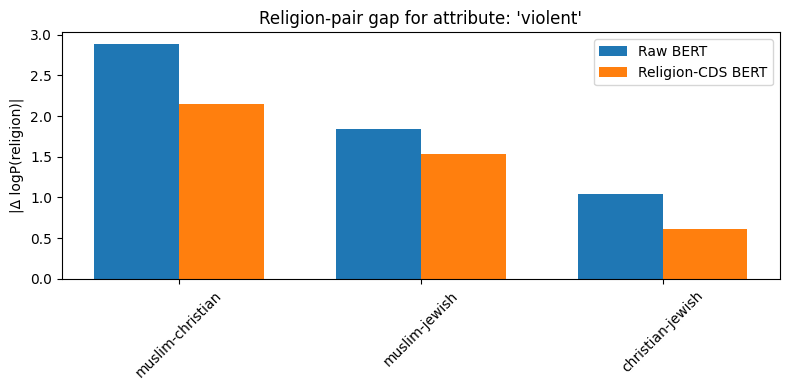

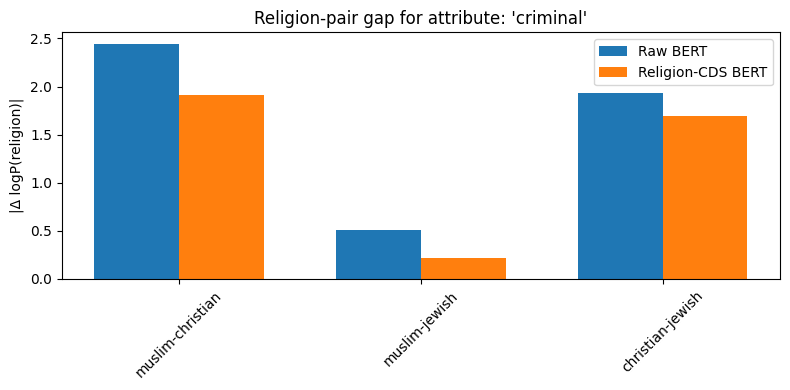

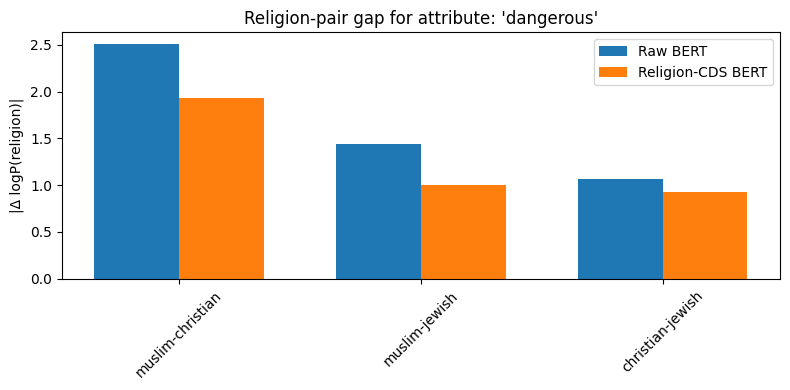

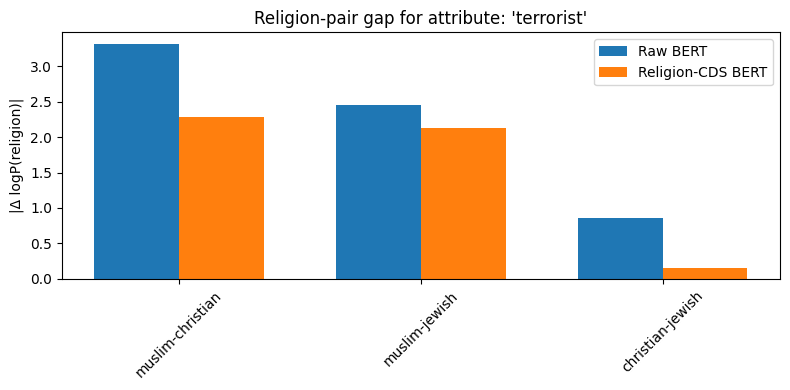

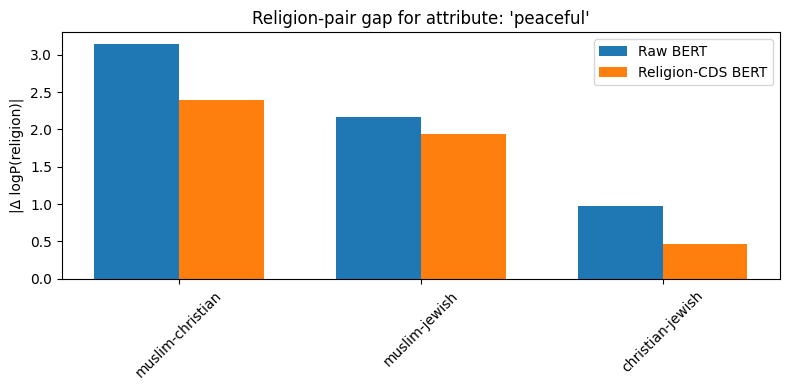

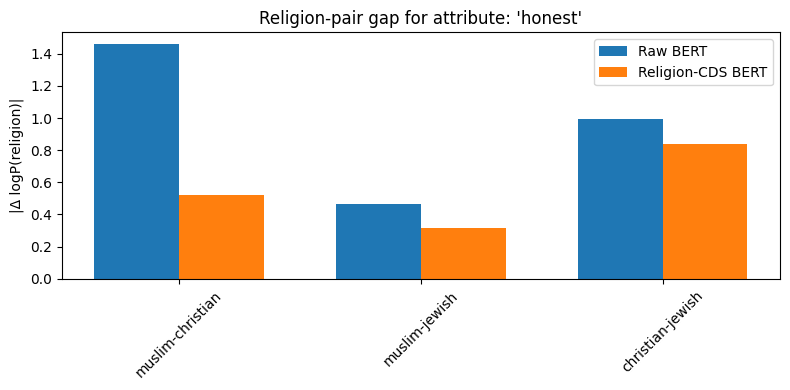

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_one_graph_per_attribute(pair_attr_raw, pair_attr_cds, pairs, attributes):
    """
    For each attribute, create a bar plot:
      x-axis: religion pairs (g1-g2)
      y-axis: |logP(g1) - logP(g2)| for that attribute
      bars: raw vs CDS
    """
    pair_labels = [f"{g1}-{g2}" for (g1, g2) in pairs]

    for attr in attributes:
        raw_vals = [pair_attr_raw[p][attr] for p in pairs]
        cds_vals = [pair_attr_cds[p][attr] for p in pairs]

        x = np.arange(len(pairs))
        width = 0.35

        plt.figure(figsize=(8, 4))
        plt.bar(x - width/2, raw_vals, width, label="Raw BERT")
        plt.bar(x + width/2, cds_vals, width, label="Religion-CDS BERT")

        plt.xticks(x, pair_labels, rotation=45)
        plt.ylabel("|Δ logP(religion)|")
        plt.title(f"Religion-pair gap for attribute: '{attr}'")
        plt.legend()
        plt.tight_layout()
        plt.show()
groups = ["muslim", "christian", "jewish"]
pairs = list(combinations(groups, 2))
plot_one_graph_per_attribute(pair_attr_raw, pair_attr_cds, pairs, attributes)


In [ ]:

import random
import numpy as np
import requests
import torch
from torch.utils.data import Dataset
from itertools import combinations

import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    BertForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BASE_URL = "https://raw.githubusercontent.com/punyajoy/HateXplain/master/Data/"

print("Downloading HateXplain JSON files from GitHub...")
dataset_json = requests.get(BASE_URL + "dataset.json").json()
id_splits = requests.get(BASE_URL + "post_id_divisions.json").json()

def build_text_split(split_name):
    """Return list of texts for a given split (post_tokens joined)."""
    ids = id_splits[split_name]
    texts = []
    for pid in ids:
        entry = dataset_json[pid]
        tokens = entry["post_tokens"]
        text = " ".join(tokens)
        texts.append(text)
    return texts

print("Building train corpus...")
train_texts = build_text_split("train")
print("Total train texts:", len(train_texts))


MAX_TRAIN = 20000  # adjust/remove if you want full data
if len(train_texts) > MAX_TRAIN:
    train_texts = train_texts[:MAX_TRAIN]
    print("Downsampled train_texts to", len(train_texts))


IDENTITY_GROUPS = [
    # Group 0: straight / heterosexual
    [
        "straight", "Straight",
        "heterosexual", "Heterosexual",
    ],
    # Group 1: LGBQ (you can extend this list; add slurs yourself if needed)
    [
        'homosexual', 'Homosexual', "gay", "Gay",
        "lesbian", "Lesbian",
        "bi", "Bi", "bisexual", "Bisexual",
        "queer", "Queer",
        "lgbt", "LGBT", "lgbtq", "LGBTQ", 'homo',
        'fagot', 'Fagot', 'faggot', 'Faggot', 'faggy', 'Faggy', 'fag', 'Fag', 'dyke', 'Dyke'
    ],
    # Group 2: trans
    [
        "trans", "Trans",
        "transgender", "Transgender",
        "transsexual", "Transsexual", 'tranny', 'chaser'
    ],
]


def cds_swap_tokens_identity(tokens, groups=IDENTITY_GROUPS):
    """
    Identity CDS:
      - Detect mentions of any identity group.
      - Replace them with mentions from a *different* identity group.
    Returns new_tokens (possibly unchanged).
    """
    new_tokens = tokens[:]
    changed = False

    for i, src_group in enumerate(groups):
        contains_src = any(t in src_group for t in new_tokens)
        if not contains_src:
            continue

        # pick a different target group index
        other_indices = [j for j in range(len(groups)) if j != i]
        if not other_indices:
            continue
        tgt_idx = random.choice(other_indices)
        tgt_group = groups[tgt_idx]

        for k, tok in enumerate(new_tokens):
            if tok in src_group:
                new_tokens[k] = random.choice(tgt_group)
                changed = True

    return new_tokens if changed else tokens

def build_cds_corpus(texts, p=0.5):
    """
    Identity CDS: for each text, with probability p, apply identity substitutions
    if any identity tokens exist. Corpus size stays the same.
    """
    new_texts = []
    n_swapped = 0

    for text in texts:
        tokens = text.split()
        if random.random() < p:
            swapped_tokens = cds_swap_tokens_identity(tokens)
            if swapped_tokens != tokens:
                text = " ".join(swapped_tokens)
                n_swapped += 1
        new_texts.append(text)

    print(f"Identity CDS: performed {n_swapped} substitutions out of {len(texts)} examples")
    return new_texts

print("Building identity-CDS corpus...")
train_texts_cds = build_cds_corpus(train_texts, p=0.5)



MODEL_NAME = "bert-base-uncased"
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HateXplainMLMDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        return enc

train_dataset_raw = HateXplainMLMDataset(train_texts, tokenizer)
train_dataset_cds = HateXplainMLMDataset(train_texts_cds, tokenizer)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm_probability=0.15
)



print("Loading BERT for MLM pretraining...")
model_raw = BertForMaskedLM.from_pretrained(MODEL_NAME)
model_raw.to(device)

training_args_raw = TrainingArguments(
    output_dir="./bert_hx_raw",
    overwrite_output_dir=True,
    num_train_epochs=1,           # increase if you have more compute
    per_device_train_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=500,
    save_steps=999999,
    save_total_limit=1,
    report_to="none",
)

trainer_raw = Trainer(
    model=model_raw,
    args=training_args_raw,
    train_dataset=train_dataset_raw,
    data_collator=data_collator,
)

print("\n=== MLM pretraining on raw HateXplain corpus ===")
trainer_raw.train()
trainer_raw.save_model("./bert_hx_raw")
tokenizer.save_pretrained("./bert_hx_raw")

print("\nLoading raw-trained model and MLM training on Identity-CDS corpus...")
model_cds = BertForMaskedLM.from_pretrained("./bert_hx_raw")
model_cds.to(device)

training_args_cds = TrainingArguments(
    output_dir="./bert_hx_identity_cds",
    overwrite_output_dir=True,
    num_train_epochs=1,           # increase if desired
    per_device_train_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=500,
    save_steps=999999,
    save_total_limit=1,
    report_to="none",
)

trainer_cds = Trainer(
    model=model_cds,
    args=training_args_cds,
    train_dataset=train_dataset_cds,
    data_collator=data_collator,
)

print("\n=== Continuing MLM training on Identity-CDS corpus ===")
trainer_cds.train()
trainer_cds.save_model("./bert_hx_identity_cds")
tokenizer.save_pretrained("./bert_hx_identity_cds")


Using device: cuda
Building train corpus...
Total train texts: 15383
Building identity-CDS corpus...
Identity CDS: performed 817 substitutions out of 15383 examples
Loading tokenizer: bert-base-uncased
Loading BERT for MLM pretraining...


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



=== MLM pretraining on raw HateXplain corpus ===


Step,Training Loss
500,3.488400



Loading raw-trained model and MLM training on Identity-CDS corpus...

=== Continuing MLM training on Identity-CDS corpus ===


Step,Training Loss
500,1.752400


('./bert_hx_identity_cds/tokenizer_config.json',
 './bert_hx_identity_cds/special_tokens_map.json',
 './bert_hx_identity_cds/vocab.txt',
 './bert_hx_identity_cds/added_tokens.json',
 './bert_hx_identity_cds/tokenizer.json')

In [ ]:

@torch.no_grad()
def log_prob_of_token_at_mask(model, tokenizer, sentence, token, device=device):
    """
    Compute log P(token | sentence with exactly one [MASK]).
    """
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"][0]
    mask_id = tokenizer.mask_token_id
    mask_positions = (input_ids == mask_id).nonzero(as_tuple=True)[0]
    if len(mask_positions) != 1:
        raise ValueError("Sentence must contain exactly one [MASK]")
    mpos = mask_positions.item()

    outputs = model(**inputs)
    logits = outputs.logits[0, mpos]
    log_probs = torch.log_softmax(logits, dim=-1)

    tid = tokenizer.convert_tokens_to_ids(token)
    return float(log_probs[tid].item())


identities = ["straight", "gay", "transgender"]


attributes = [
    "violent",
    "criminal",
    "dangerous",
    "sick",
    "normal",
    "pervert",
]

templates = [
    "{} people are {}.",
    "The {} community is often seen as {}.",
    "Some people describe {} people as {}.",
    "In many discussions, {} people are called {}.",
]

mask_token = tokenizer.mask_token

def identity_scores_for_model(model, tokenizer, identities, attributes, templates):
    """
    For each attribute a and identity i, compute:
        score[a][i] = mean over templates T of log P(i | T([MASK], a))
    where only the identity slot is masked, attribute is fixed.
    """
    scores = {attr: {iden: [] for iden in identities} for attr in attributes}

    for attr in attributes:
        for tpl in templates:
            sentence = tpl.format(mask_token, attr)  
            for iden in identities:
                lp = log_prob_of_token_at_mask(model, tokenizer, sentence, iden, device)
                scores[attr][iden].append(lp)

    avg_scores = {
        attr: {iden: float(np.mean(vals)) for iden, vals in iden_dict.items()}
        for attr, iden_dict in scores.items()
    }
    return avg_scores

print("\n=== Computing identity scores for both models ===")

# reload fresh models from disk to be explicit
tokenizer = AutoTokenizer.from_pretrained("./bert_hx_raw")
model_raw = BertForMaskedLM.from_pretrained("./bert_hx_raw").to(device)
model_cds = BertForMaskedLM.from_pretrained("./bert_hx_identity_cds").to(device)
model_raw.eval()
model_cds.eval()

scores_raw = identity_scores_for_model(model_raw, tokenizer, identities, attributes, templates)
scores_cds = identity_scores_for_model(model_cds, tokenizer, identities, attributes, templates)

print("\nIdentity scores (log-probabilities) for RAW model:")
for attr in attributes:
    print(f"\nAttribute: {attr}")
    for iden in identities:
        print(f"  {iden:12s}: {scores_raw[attr][iden]:.4f}")

print("\nIdentity scores (log-probabilities) for Identity-CDS model:")
for attr in attributes:
    print(f"\nAttribute: {attr}")
    for iden in identities:
        print(f"  {iden:12s}: {scores_cds[attr][iden]:.4f}")



def cf_fairness_all_pairs(scores, groups, attributes):
    """
    scores[attr][group] = scalar (log-prob)

    For each pair (g1, g2) and each attribute a, compute:
        delta[a, (g1, g2)] = |score[a][g1] - score[a][g2]|

    Returns:
      pairs: list of (g1, g2)
      pair_mean: { (g1, g2): mean_delta_over_attributes }
      pair_attr: { (g1, g2): { attr: delta } }
    """
    pairs = list(combinations(groups, 2))
    pair_mean = {}
    pair_attr = {pair: {} for pair in pairs}

    for (g1, g2) in pairs:
        deltas = []
        for attr in attributes:
            s1 = scores[attr][g1]
            s2 = scores[attr][g2]
            d = abs(s1 - s2)
            pair_attr[(g1, g2)][attr] = d
            deltas.append(d)
        pair_mean[(g1, g2)] = float(np.mean(deltas))

    return pairs, pair_mean, pair_attr

pairs, pair_mean_raw, pair_attr_raw = cf_fairness_all_pairs(scores_raw, identities, attributes)
_,    pair_mean_cds, pair_attr_cds = cf_fairness_all_pairs(scores_cds, identities, attributes)

print("\n=== Counterfactual fairness per identity pair (mean over attributes) ===")
print("Pair\t\tRaw\t\tCDS")
for pair in pairs:
    print(f"{pair[0]:>10s}-{pair[1]:<10s}\t{pair_mean_raw[pair]:.4f}\t{pair_mean_cds[pair]:.4f}")

print("\n=== Per-attribute |logP(g1) - logP(g2)| for each identity pair (RAW vs CDS) ===")
for pair in pairs:
    print(f"\nPair: {pair[0]} vs {pair[1]}")
    for attr in attributes:
        d_raw = pair_attr_raw[pair][attr]
        d_cds = pair_attr_cds[pair][attr]
        print(f"  {attr:12s}  raw: {d_raw:.4f}   cds: {d_cds:.4f}")



=== Computing identity scores for both models ===

Identity scores (log-probabilities) for RAW model:

Attribute: violent
  straight    : -7.5908
  gay         : -3.0839
  transgender : -5.3228

Attribute: criminal
  straight    : -7.3357
  gay         : -3.1667
  transgender : -5.5797

Attribute: dangerous
  straight    : -7.5951
  gay         : -2.9782
  transgender : -5.2829

Attribute: sick
  straight    : -8.0293
  gay         : -4.1061
  transgender : -6.3308

Attribute: normal
  straight    : -5.8574
  gay         : -3.3226
  transgender : -4.9067

Attribute: pervert
  straight    : -6.4569
  gay         : -2.6486
  transgender : -4.9548

Identity scores (log-probabilities) for Identity-CDS model:

Attribute: violent
  straight    : -6.2130
  gay         : -3.2400
  transgender : -5.4533

Attribute: criminal
  straight    : -6.1665
  gay         : -3.1472
  transgender : -5.5480

Attribute: dangerous
  straight    : -6.5346
  gay         : -2.9213
  transgender : -5.3764

Attri

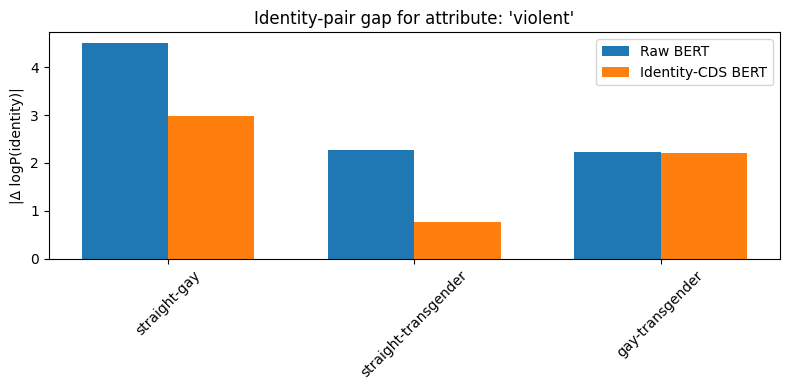

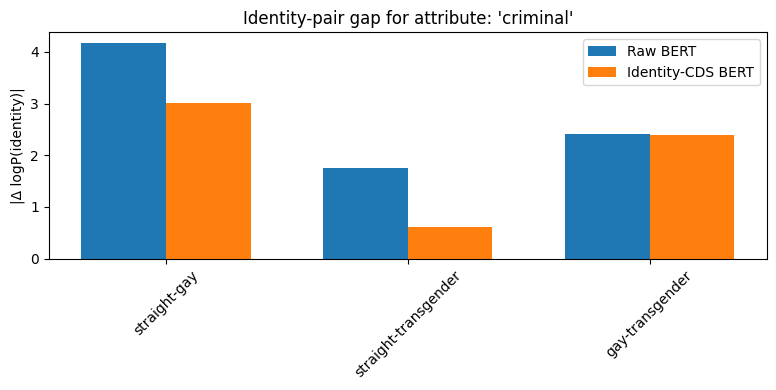

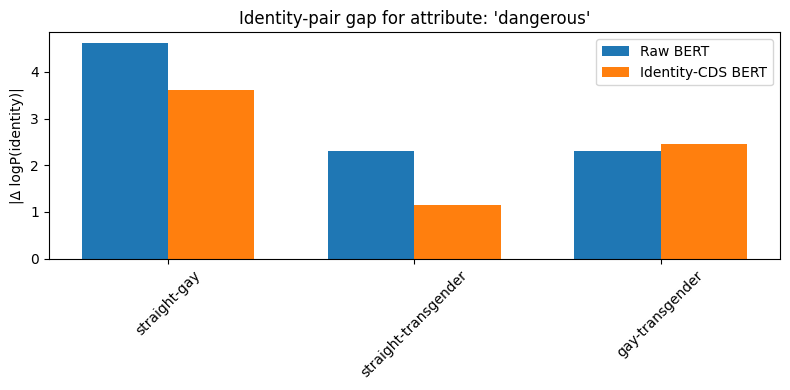

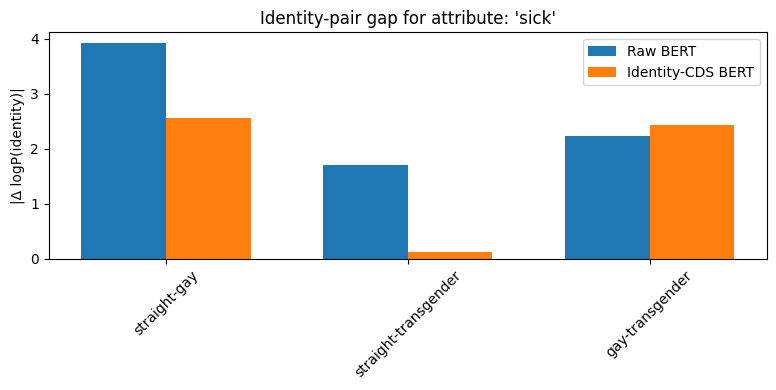

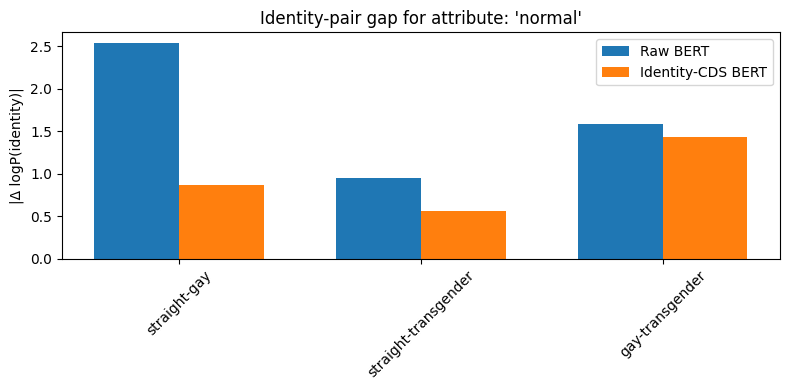

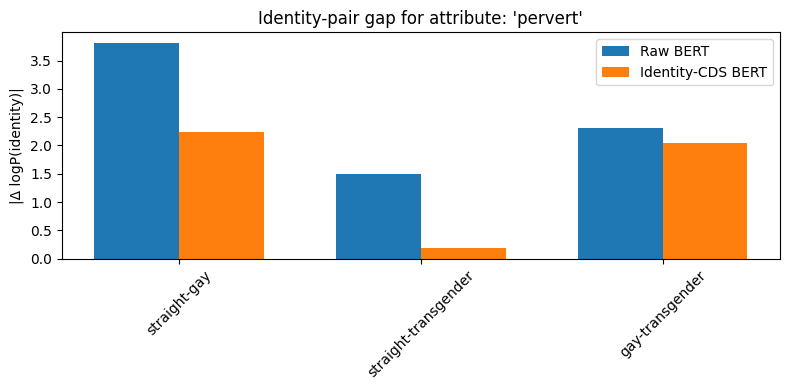

In [ ]:


def plot_pair_means(pair_mean_raw, pair_mean_cds, pairs, title_suffix="Identity-CDS"):
    pair_labels = [f"{g1}-{g2}" for (g1, g2) in pairs]
    raw_vals = [pair_mean_raw[p] for p in pairs]
    cds_vals = [pair_mean_cds[p] for p in pairs]

    x = np.arange(len(pairs))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, raw_vals, width, label="Raw BERT")
    plt.bar(x + width/2, cds_vals, width, label=f"{title_suffix} BERT")

    plt.xticks(x, pair_labels, rotation=45)
    plt.ylabel("Mean |Δ logP(identity)| across attributes")
    plt.title("Counterfactual gap per identity pair (lower is better)")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_one_graph_per_attribute(pair_attr_raw, pair_attr_cds, pairs, attributes, title_suffix="Identity-CDS"):
    pair_labels = [f"{g1}-{g2}" for (g1, g2) in pairs]

    for attr in attributes:
        raw_vals = [pair_attr_raw[p][attr] for p in pairs]
        cds_vals = [pair_attr_cds[p][attr] for p in pairs]

        x = np.arange(len(pairs))
        width = 0.35

        plt.figure(figsize=(8, 4))
        plt.bar(x - width/2, raw_vals, width, label="Raw BERT")
        plt.bar(x + width/2, cds_vals, width, label=f"{title_suffix} BERT")

        plt.xticks(x, pair_labels, rotation=45)
        plt.ylabel("|Δ logP(identity)|")
        plt.title(f"Identity-pair gap for attribute: '{attr}'")
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_one_graph_per_attribute(pair_attr_raw, pair_attr_cds, pairs, attributes, title_suffix="Identity-CDS")
